# glTF export and surface normals

[glTF 2.0](https://registry.khronos.org/glTF/specs/2.0/glTF-2.0.html) is the web's 3-D format: three.js, Blender, model viewers and dashboards load it with no meshio++ in the loop. meshio++ writes it (`.glb` binary, or `.gltf` with a `.bin` beside it) from any mesh: the **skin** of volume cells, 2-D cells, lines and point clouds, one named node per cell region.

glTF normals are **per vertex**, so a hard edge needs its position twice. That is what `compute_normals` does when you give it a `split_angle`, and the glTF writer runs the same kernel. This notebook builds an L-shaped bracket, looks at the normals, writes it as a coloured `.glb`, decodes the file by hand the way a viewer would, and checks that the source coordinates come back.

In [1]:
import json
import os
import struct
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

TMP = tempfile.mkdtemp()


def to_grid(mesh):
    """meshio++ Mesh -> PyVista grid via a temporary .vtu."""
    path = os.path.join(TMP, 'render.vtu')
    mp.write(path, mesh)
    return pv.read(path)


def gallery(builders, titles, size=(760, 560)):
    """Render each `builder(plotter)` side by side; fall back to a note when GL is unavailable."""
    fig = plt.figure(figsize=(6.2 * len(builders), 5.0))
    for k, (build, title) in enumerate(zip(builders, titles), start=1):
        ax = fig.add_subplot(1, len(builders), k)
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            if not build(pl):                      # a builder that sets its own camera returns True
                pl.camera_position = 'iso'
            img = pl.screenshot(return_img=True)
            pl.close()
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            ax.text(0.5, 0.5, 'PyVista render skipped:\n' + str(exc)[:80], ha='center', va='center')
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## An L-shaped bracket

A structured hexahedron mesh with the inner corner removed, carrying a temperature-like point field, two **cell regions** (`flange`, the horizontal slab, and `web`, the vertical one) and a boundary patch, `load`, as a `quad` block on the top face. The patch matters below: the writer exports a boundary cell instead of the skin facet it coincides with.

In [2]:
nx, ny, nz = 12, 6, 4                     # cells along x, y, z
xs, ys, zs = np.arange(nx + 1.0), np.arange(ny + 1.0), np.arange(nz + 1.0)
X, Y, Z = np.meshgrid(xs, ys, zs, indexing='ij')
all_points = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
pid = lambda i, j, k: (i * (ny + 1) + j) * (nz + 1) + k

hexes, part = [], []
for i in range(nx):
    for j in range(ny):
        for k in range(nz):
            web = i < 4                      # the vertical slab, x in [0, 4]
            flange = j < 2                   # the horizontal slab, y in [0, 2]
            if not (web or flange):
                continue                     # the removed inner corner
            hexes.append([pid(i, j, k), pid(i + 1, j, k), pid(i + 1, j + 1, k), pid(i, j + 1, k),
                          pid(i, j, k + 1), pid(i + 1, j, k + 1), pid(i + 1, j + 1, k + 1), pid(i, j + 1, k + 1)])
            part.append(0 if flange else 1)
hexes, part = np.array(hexes), np.array(part)

used = np.unique(hexes)
remap = -np.ones(len(all_points), dtype=int)
remap[used] = np.arange(len(used))
points, hexes = all_points[used], remap[hexes]

# A load patch: the quads of the top face (z = nz) of the flange, as their own block.
top = np.flatnonzero((points[:, 2] == nz))
top_set = set(top.tolist())
patch = [[h[4], h[5], h[6], h[7]] for h in hexes if set(h[4:8]) <= top_set and points[h[4], 1] < 2]
patch = np.array(patch)

# A field that grows away from a hot spot at the origin.
temperature = 300.0 + 40.0 * np.exp(-np.linalg.norm(points - points[0], axis=1) / 6.0) * 5

flange_cells = np.flatnonzero(part == 0)
web_cells = np.flatnonzero(part == 1)
mesh = mp.Mesh(
    points,
    [('hexahedron', hexes), ('quad', patch)],
    point_data={'temperature': temperature},
    regions=[
        mp.Region('flange', 'cell', flange_cells),
        mp.Region('web', 'cell', web_cells),
        mp.Region('load', 'cell', len(hexes) + np.arange(len(patch))),
    ],
)
print(mesh)
print('regions:', {r.name: len(r.entries) for r in mesh.regions})

<meshio++ mesh object>
  Number of points: 295
  Number of cells:
    hexahedron: 160
    quad: 24
  Cell sets: flange, web, load
  Point data: temperature
regions: {'flange': 96, 'web': 64, 'load': 24}


## Normals belong to a smooth patch, not to a position

The skin of the bracket has hard edges everywhere. `compute_normals(skin)` returns one normal per point — the angle-weighted mean of the incident faces — which at a hard edge is right for none of them. With a `split_angle` the corners around a vertex are grouped into smooth fans and every fan beyond the first gets its own copy of the point, so each point carries exactly one normal. The copies are appended after the original points (the layout `repair` uses for its bowtie copies), cells keep their numbering, and `point_data` follows by row.

The arrows below are the point normals: on the left one per point, tilted across every hard edge; on the right one per smooth fan, each along its own faces.

skin points          : 226
smooth normals       : (226, 3)
split at 30 degrees  : 328 points, 102 added, 90 of the original points split
parent of the copies : [ 0  1  0  5 35  2  3  4] ...
input surface        : {'boundary_edges': 0, 'non_manifold_edges': 0, 'inconsistent_pairs': 0, 'degenerate_triangles': 0, 'watertight': True}


meshio warning [region_remap.cpp:226] extract_skin: 3 named region(s) dropped — the output cells and points are newly created and have no correspondence with the input's


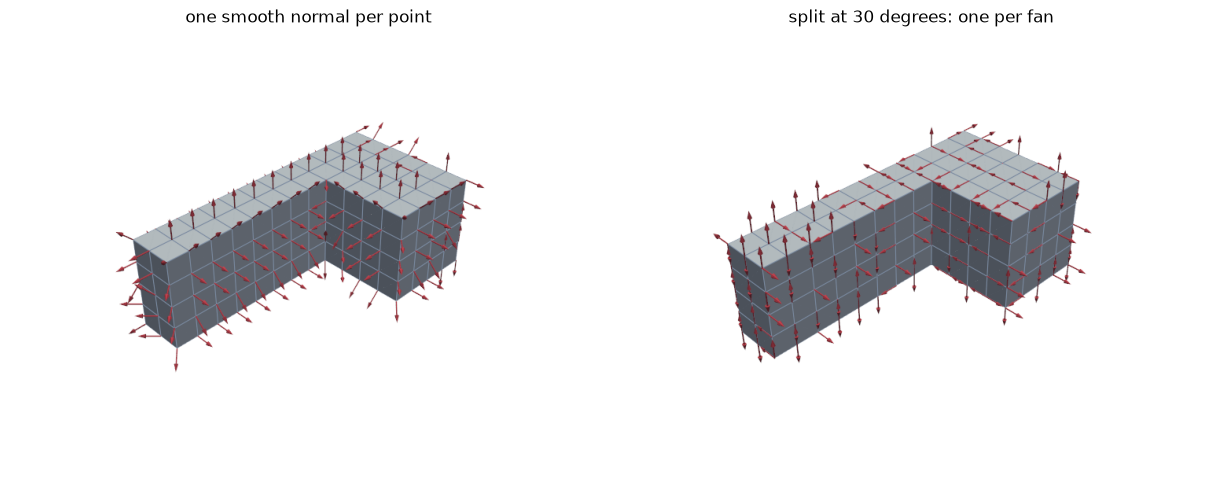

In [3]:
skin = mp.extract_skin(mesh, linearize=True)
smooth = mp.compute_normals(skin)
split, report = mp.compute_normals(skin, split_angle=30, record_parent_ids=True, return_report=True)

print('skin points          :', len(skin.points))
print('smooth normals       :', smooth.point_data['normals'].shape)
print('split at 30 degrees  :', len(split.points), 'points,', report['num_added_points'], 'added,',
      report['num_split_points'], 'of the original points split')
print('parent of the copies :', split.point_data['normals:parent_point'][len(skin.points):][:8], '...')
print('input surface        :', report['quality'])


def arrows(mesh_with_normals):
    def build(pl):
        grid = to_grid(mesh_with_normals)
        grid = grid.extract_surface(algorithm='dataset_surface') if hasattr(grid, 'extract_surface') else grid
        pl.add_mesh(grid, color='#c9d6e8', show_edges=True, edge_color='#7a8aa0', line_width=0.4)
        grid.point_data['Normals'] = mesh_with_normals.point_data['normals']
        pl.add_mesh(grid.glyph(orient='Normals', scale=False, factor=0.9), color='#d1495b')
    return build


gallery([arrows(smooth), arrows(split)], ['one smooth normal per point', 'split at 30 degrees: one per fan'])

A `split_angle` of 180 keeps every manifold pair smooth, so on a closed, consistently wound surface it is the unsplit result bit for bit; `0` puts every face on its own points. Boundary edges, non-manifold edges and triangles that are wound the same way always cut — `compute_normals` never reorients, so the report's `inconsistent_pairs` tells you when to run `repair` first.

## Write it as glTF

`mp.write('bracket.glb', mesh)` writes the defaults. Here the temperature is baked through a colormap into `COLOR_0`, and the material becomes `KHR_materials_unlit` so shading cannot distort the colour reading. The bracket is Z-up CAE data in millimetres, so `up_axis` and `scale` go on the root node rather than into the coordinates.

In [4]:
path = os.path.join(TMP, 'bracket.glb')
mp.gltf.write(path, mesh, color_by='temperature', cmap='turbo', split_angle=30, scale=0.001)
print(os.path.getsize(path), 'bytes')


def read_glb(path):
    """(json, bin) of a GLB."""
    data = open(path, 'rb').read()
    magic, version, length = struct.unpack_from('<III', data, 0)
    assert magic == 0x46546C67 and version == 2 and length == len(data)
    off, chunks = 12, []
    while off < len(data):
        n, kind = struct.unpack_from('<II', data, off)
        chunks.append(data[off + 8: off + 8 + n])
        off += 8 + n
    return json.loads(chunks[0]), chunks[1]


doc, blob = read_glb(path)
print(doc['asset'])
print('nodes   :', [n['name'] for n in doc['nodes']])
print('meshes  :', [(m['name'], [p['mode'] for p in m['primitives']]) for m in doc['meshes']])
print('root    :', {k: v for k, v in doc['nodes'][0].items() if k != 'children'})
print('extensions used:', doc.get('extensionsUsed'))
print('attributes:', sorted(doc['meshes'][0]['primitives'][0]['attributes']))

22312 bytes
{'generator': 'Written by meshio++ v15.4.0', 'version': '2.0'}
nodes   : ['meshio++', 'flange', 'load', 'web']
meshes  : [('flange', [4]), ('load', [4]), ('web', [4])]
root    : {'name': 'meshio++', 'rotation': [-0.7071067811865476, 0, 0, 0.7071067811865476], 'scale': [0.001, 0.001, 0.001], 'translation': [0.006, 0.002, -0.003]}
extensions used: ['KHR_materials_unlit']
attributes: ['COLOR_0', 'NORMAL', 'POSITION', '_TEMPERATURE']


There is one node per cell region — `flange`, `web` and the `load` patch, which replaced the skin facets it coincides with instead of z-fighting with them. The point field rides along raw as `_TEMPERATURE`, and `COLOR_0` carries the baked colour.

## What a viewer sees

A glTF viewer applies the root node's transform, treats `COLOR_0` as **linear**, and displays in sRGB. The next cell decodes the file that way — nothing but `struct` and NumPy — and renders it. The root node rotates the Z-up source into glTF's Y-up world and applies the millimetre scale; the translation is the bounding-box centre that `recenter` subtracted, so world coordinates are the source coordinates.

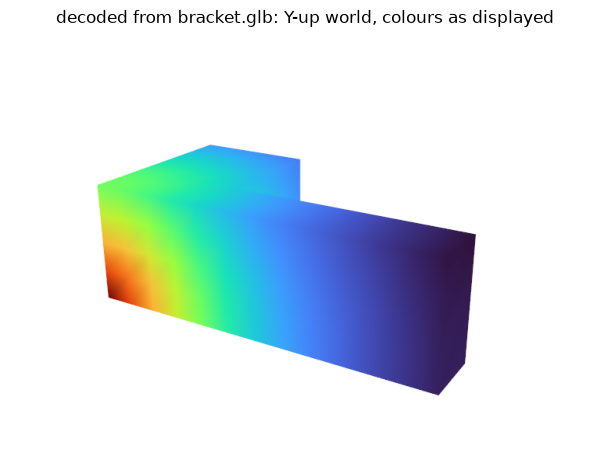

vertices 343 | triangles 448


In [5]:
def accessor(index):
    acc = doc['accessors'][index]
    view = doc['bufferViews'][acc['bufferView']]
    ncomp = {'SCALAR': 1, 'VEC2': 2, 'VEC3': 3, 'VEC4': 4}[acc['type']]
    dtype = {5125: '<u4', 5126: '<f4'}[acc['componentType']]
    arr = np.frombuffer(blob[view['byteOffset']: view['byteOffset'] + view['byteLength']], dtype=dtype)
    return arr.reshape(-1, ncomp) if ncomp > 1 else arr


def srgb(linear):
    linear = np.clip(linear, 0.0, 1.0)
    return np.where(linear <= 0.0031308, 12.92 * linear, 1.055 * np.power(linear, 1 / 2.4) - 0.055)


def node_matrix(root):
    x, y, z, w = root.get('rotation', [0, 0, 0, 1])
    rot = np.array([[1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w)],
                    [2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w)],
                    [2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y)]])
    return rot, np.array(root.get('scale', [1, 1, 1])), np.array(root['translation'])


rot, scale, translation = node_matrix(doc['nodes'][0])
world, faces, colors = [], [], []
for m in doc['meshes']:
    for prim in m['primitives']:
        pos = accessor(prim['attributes']['POSITION']).astype(float)
        world.append((pos * scale) @ rot.T + translation)
        idx = accessor(prim['indices']).reshape(-1, 3) + sum(len(w) for w in world[:-1])
        faces.append(idx)
        colors.append(srgb(accessor(prim['attributes']['COLOR_0'])))
world, faces, colors = np.vstack(world), np.vstack(faces), np.vstack(colors)

poly = pv.PolyData(world, np.column_stack([np.full(len(faces), 3), faces]).ravel())
poly.point_data['rgb'] = (colors * 255).astype(np.uint8)


def viewer(pl):
    pl.add_mesh(poly, scalars='rgb', rgb=True, show_edges=False, lighting=False)
    centre = np.array(poly.center)
    diagonal = np.linalg.norm(np.array(poly.bounds[1::2]) - np.array(poly.bounds[0::2]))
    # A Y-up camera, as a glTF viewer has: the bracket's source z axis is now the vertical.
    pl.camera_position = [tuple(centre + diagonal * np.array([0.9, 0.7, 1.5])), tuple(centre), (0, 1, 0)]
    return True


gallery([viewer], ['decoded from bracket.glb: Y-up world, colours as displayed'])
print('vertices', len(world), '| triangles', len(faces))

## The source coordinates come back exactly

The transform is a permutation with signs, so applying it to the exported vertices must land on the source points — scaled by 0.001, Y-up. Every source point of the skin should be a vertex of the file (a hard edge appears several times).

In [6]:
src = skin.points * 0.001
expected = np.column_stack([src[:, 0], src[:, 2], -src[:, 1]])                      # z-up -> y-up
tree_check = {tuple(np.round(p, 9)) for p in expected}
found = {tuple(np.round(p, 9)) for p in world}
print('every exported vertex is a source point   :', found <= tree_check)
print('every skin point is exported              :', tree_check <= found)
print('largest |coordinate| in the file          :', float(np.abs(accessor(doc['meshes'][0]['primitives'][0]['attributes']['POSITION'])).max()),
      '(recentred, so it stays small)')

every exported vertex is a source point   : True
every skin point is exported              : True
largest |coordinate| in the file          : 6.0 (recentred, so it stays small)


## Point clouds and lines come along

A mesh with no cells — how a `.pcd` or `.xyz` cloud arrives — becomes one `POINTS` primitive, keeping its `normals` when it has them. `compute_normals` followed by `write('cloud.glb', ...)` is the whole route from a surface to a shaded point cloud on the web.

In [7]:
cloud = mp.Mesh(split.points, [], point_data={'normals': split.point_data['normals'],
                                              'temperature': np.interp(split.points[:, 0], [0, 12], [300, 500])})
cpath = os.path.join(TMP, 'cloud.glb')
mp.write(cpath, cloud)
cdoc, _ = read_glb(cpath)
prim = cdoc['meshes'][0]['primitives'][0]
print('mode', prim['mode'], '(0 = POINTS) | attributes', sorted(prim['attributes']), '| indices:', 'indices' in prim)

mode 0 (0 = POINTS) | attributes ['NORMAL', 'POSITION', '_TEMPERATURE'] | indices: False


## Options, and how it is checked

| | |
|---|---|
| `split_angle`, `normal_weight`, `normals` | crease angle in degrees (`[0, 180]`), `"angle"`/`"area"` weighting, `normals=False` to share vertices |
| `fields` | every 1–4 component `point_data` array as a raw `_NAME` attribute |
| `color_by`, `component`, `cmap`, `vmin`, `vmax`, `nan_color`, `unlit` | bake a `point_data` or `cell_data` array into linear `COLOR_0` |
| `up_axis`, `scale`, `recenter` | root-node rotation, unit scale and centring offset |
| `by_region`, `container` | one node per cell region, and `.glb` versus `.gltf` + `.bin` |

The C++ core and the Python reference write **identical bytes**, and the output passes the Khronos [glTF-Validator](https://github.com/KhronosGroup/glTF-Validator) with zero errors and warnings (a CI job runs it). The command line reaches the same writer: `meshioplusplus convert bracket.vtu bracket.glb --color-by temperature --split-angle 30`.